PREVISÃO DE SÉRIES TEMPORAIS

In [ ]:
%pip install -U pmdarima sktime

In [ ]:
import sktime
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from sktime.forecasting.base import ForecastingHorizon
from sktime.performance_metrics.forecasting import mean_squared_error
from sktime.forecasting.arima import ARIMA
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.theta import ThetaForecaster
from sktime.forecasting.exp_smoothing import ExponentialSmoothing

Fazendo upload do arquivo que contém o dataset US Births, que consiste em uma série temporal longa de frequência **diária** que representa o número de nascimentos de 01/01/1969 até 31/12/1988 nos Estados Unidos. Tem-se, portanto, um período de 20 anos, totalizando 7305 dias (sendo esse, também, o tamanho da série).

In [ ]:
uploaded = files.upload()
dataset_file = list(uploaded.keys())[0]

Saving us_births_dataset.tsf to us_births_dataset (3).tsf


Fazendo a leitura do dataset como um DataFrame (estrutura bidimensional)

OBS: Os arquivos de datasets oferecidos em  [forecastingdata.org](https://forecastingdata.org/) são do formato .tsf, não o usual .csv (comma separted values).

In [ ]:
df = pd.read_csv(
    # arquivo do dataset (formato .tsf)
    dataset_file,
    # separador - tab
    sep="\t",
    # evita que seja ignorada a 1a linha (como cabeçalho)
    header=None,
    # tendo em vista que os valores dos dados começam, de fato, apenas na linha
    # 15, ignora-se as 15 primeiras
    skiprows=15
)

Para capturar apenas os valores da série, fazemos dois splits seguidos e convertemos os valores para inteiros. Após isso, convertemos a lista para Series, uma estrutura de dados unidimensional.

In [ ]:
series_raw = df.iloc[0, 0]

# captura apenas o que está escrito após "T1:1969-01-01 00-00-00:", separa por
# vírgula e converte para inteiro
parts = series_raw.split(":")
valuesstr = parts[2]
values = valuesstr.split(",")
values = pd.to_numeric(values)

# converte a lista para a estrutura Series
y = pd.Series(values)

# ordena os valores por data a partir de 01/01/1969
y.index = pd.date_range(
    start="1969-01-01",
    periods=len(y),
    freq="D"
)

# demonstração das 10 primeiras linhas de y
y.name = "Births"
y.head(10)

,Births
1969-01-01,8486
1969-01-02,9002
1969-01-03,9542
1969-01-04,8960
1969-01-05,8390
1969-01-06,9560
1969-01-07,9738
1969-01-08,9734
1969-01-09,9434
1969-01-10,10042


Esta é uma representação gráfica da série temporal na frequência diária. Dado o alto número de valores (pontos), a linha fica mais grossa.  

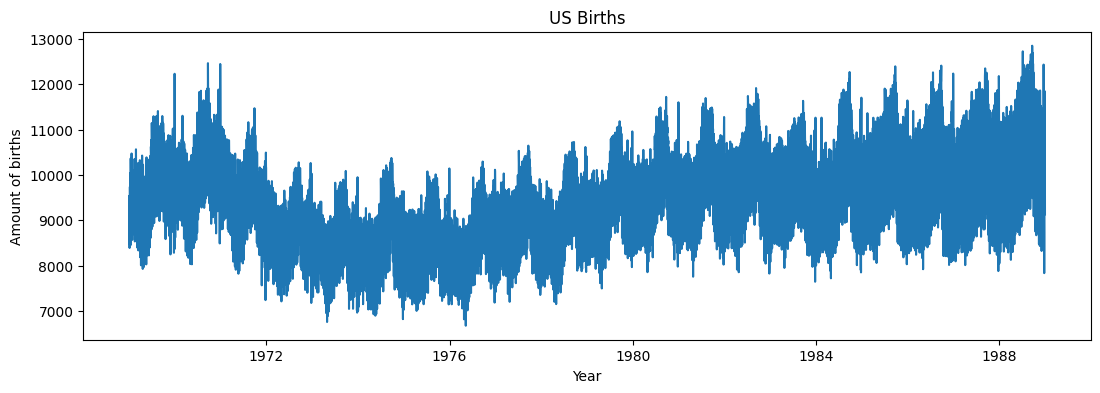

In [ ]:
plt.figure(figsize=(13,4))
plt.plot(y)
plt.title("US Births")
plt.xlabel("Year")
plt.ylabel("Amount of births")
plt.show()

Aqui, temos a visualização do gráfico com a média mensal. A linha é mais fina em virtude da menor quantidade de dados na amostra.

Observando os "picos" que ocorrem numa frequência anual, pode-se afirmar que a série US Births é de **sazonalidade anual**.

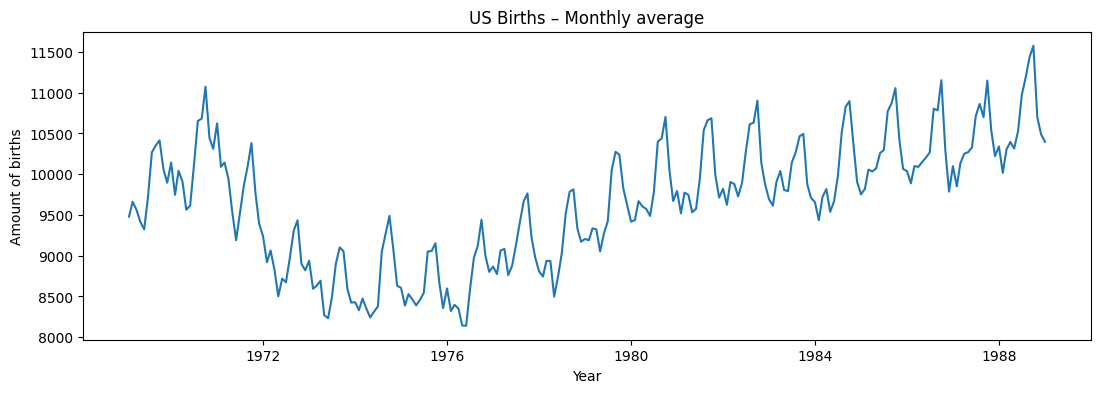

In [ ]:
# faz um resample de frequência mensal e calcula a média de cada mês
y_monthly = y.resample("ME").mean()

plt.figure(figsize=(13,4))
plt.plot(y_monthly)
plt.title("US Births – Monthly average")
plt.xlabel("Year")
plt.ylabel("Amount of births")
plt.show()

Separando os dados de treinamento e teste. Usamos uma proporção de 80% para treinamento e 20% para testes.

In [ ]:
trainsize = int(len(y)*0.8)

# os dados de treinos serão os 80% primeiros para prever os 20% últimos
y_train = y.iloc[0:trainsize]
y_test = y.iloc[trainsize:len(y)]

O horizonte de previsão (forecasting horizon) representa o período para o qual se prevê os valores com base na série observada. Desse modo, usamos y_test.index (que é o vetor de datas).

In [ ]:
# o horizonte de previsão definido não é relativo, uma vez que tem datas
# definidas. os modelos deverão prever os valores para os valores de teste
fh = ForecastingHorizon(y_test.index, is_relative=False)

Definimos um método padrão de avaliação dos modelos.

Como métrica de avaliação da acurácia dos modelos usamos **RMSE** (root mean squared error).

RMSE é calculado pela raiz quadrada de MSE (mean squared error), que consiste na média dos quadrados das diferenças entre as saídas dos modelos e os valores esperados. O MSE, por ser quadrático, penaliza ainda mais os erros mais significativos. O RMSE, por sua vez, é notado na unidade da variável original, facilitando a interpretação do erro do modelo. Uma vez que estaremos comparando 5 modelos distintos, o uso de RMSE se adequa tanto pelo rigor quanto pela notação mais facilmente compreensível.

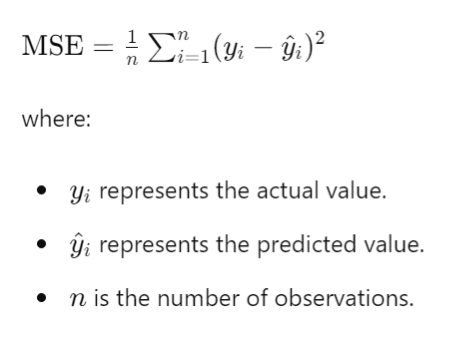

In [ ]:
def evaluating_models(model, name):
  # o método fit treina o modelo
  model.fit(y_train)
  # previsão do modelo para os valores de teste
  y_prediction = model.predict(fh)

  # calculando o erro usando RMSE como métrica
  mse = mean_squared_error(y_test, y_prediction)
  rmse = mse**0.5

  return [name, rmse]

Os modelos de previsão (forecasters) escolhidos para a avaliação foram:

1) ARIMA
2) Naive (com a estratégia mean)
3) Naive (com a estratégia drift)
4) Theta
5) Exponential Smoothing

In [ ]:
# modelo 1 - ARIMA

model1 = ARIMA(order=(1, 1, 1))
res1 = evaluating_models(model1, 'ARIMA')

In [ ]:
# modelo 2 - Naive (estratégia mean)

# estratégia: usa a média dos valores
model2 = NaiveForecaster(strategy="mean")
res2 = evaluating_models(model2, "Naive Mean")

In [ ]:
# modelo 3 - Naive (estratégia drift)

# estratégia: observa o padrâo de cresc./descresc. e repete
model3 = NaiveForecaster(strategy="drift")
res3 = evaluating_models(model3, "Naive Drift")

In [ ]:
# modelo 4 - Theta

# sp = 365: sazonalidade anual (365 valores constituem um período)
model4 = ThetaForecaster(sp=365)
res4 = evaluating_models(model4, "Theta")

In [ ]:
# modelo 5 - Exponential Smoothing

# sp = 365: sazonalidade anual (365 valores constituem um período)
# tendência e sazonalidade são aditivas
model5 = ExponentialSmoothing(trend='add', seasonal='add', sp=365)
res5 = evaluating_models(model5, "Exponential Smoothing")

In [ ]:
results_models = [res1, res2, res3, res4, res5]

result = pd.DataFrame(
    results_models,
    columns=['Model', 'RMSE']
)

result

,Model,RMSE
0,ARIMA,1194.141522
1,Naive Mean,1541.094172
2,Naive Drift,1177.700198
3,Theta,1208.762692
4,Exponential Smoothing,1254.472377


**CONCLUSÕES:**

Ordenando os modelos de previsão (forecasters) da melhor para a pior performance, temos:

1º) Naive com estratégia Drift - erro de 1177.70

2º) ARIMA - erro de 1194.14

3º) Theta - erro de 1208.76

4º) Exponential Smoothing - erro de 1254.47

5º) Naive com estratégia Mean - erro de 1541.09

**OBSERVAÇÕES:**

Por ser uma série diária, de muitas observações com pequenos intervalos, é esperado que o erro seja um pouco maior, considerando que também é maior o ruído relativo.

O pior colocado, Naive Mean, consiste basicamente no cálculo da média aritmética dos valores de observação que é repetida na previsão. Essa estratégia que é, notoriamente simplória, não apresentou bons resultados na previsão da série observada muito provavelmente pelo fato de que os valores iniciais apresentam um descrescimento considerável em relação aos últimos.

FUNCIONAMENTO DO MODELO NAIVE DRIFT:
O modelo calcula a diferença do último e primeiro valores dos dados de treinamento da série e divide-o pela quantidade de "passos" dados. Esse valor é chamado drift ou tendência média.

Ao observar a leve tendência/inclinação positiva ao final da série, é possível assumir que o sucesso desse modelo se dê exatamente pelo fato de sua previsão consistir numa série progressiva com valores que são gradativamente incrementados por uma razão.

É curioso observar como os modelos Naive e ARIMA obtiveram resultados tão próximos, apesar de ARIMA contar com um nível de complexidade bem maior do que Naive, além de possuir mais camadas de abstração para realizar a previsão.

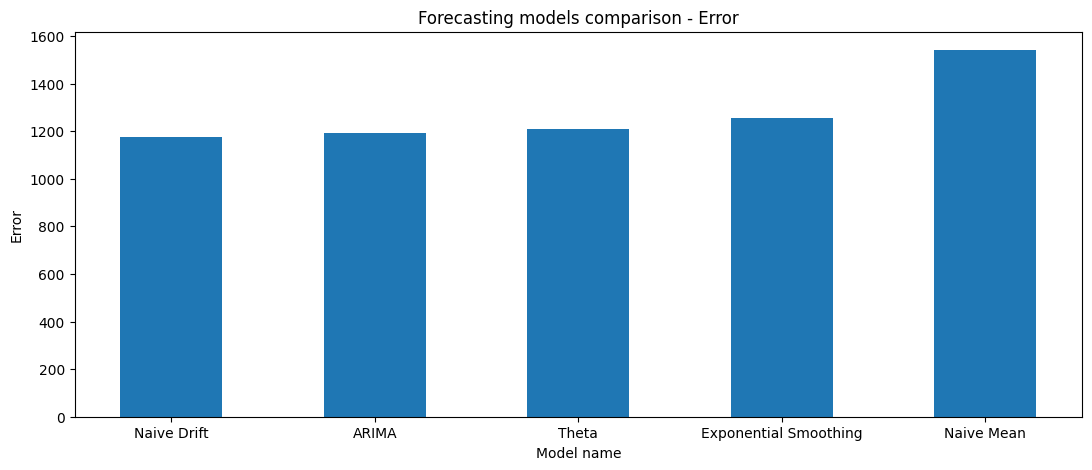

In [ ]:
result_sorted = result.sort_values("RMSE")

plt.figure(figsize=(13,5))
plt.bar(result_sorted['Model'], result_sorted['RMSE'], width=0.5)
plt.ylabel("Error")
plt.xlabel("Model name")
plt.title("Forecasting models comparison - Error")
plt.show()